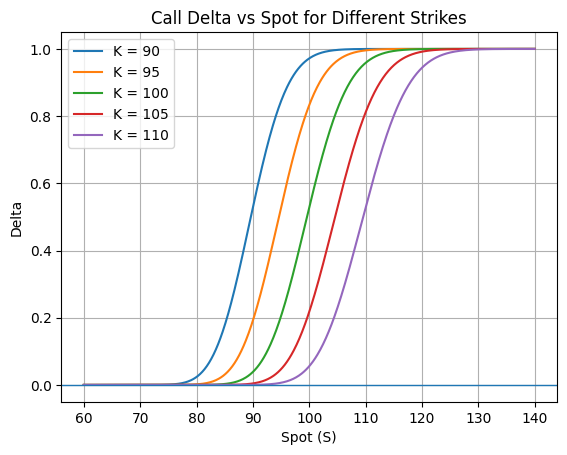

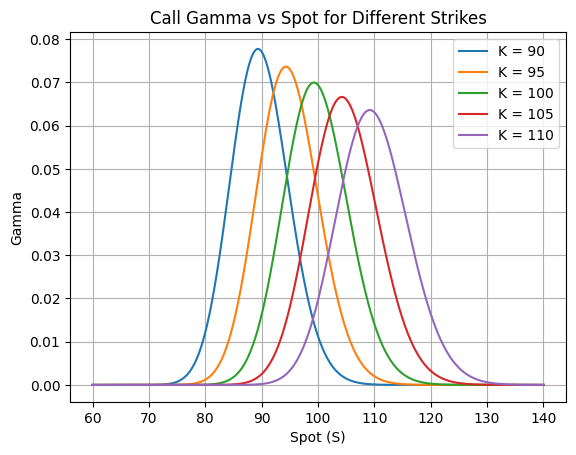

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi
from scipy.stats import norm

# -----------------------------
# Black–Scholes call greeks
# -----------------------------
def bs_call_delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def bs_call_gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

# -----------------------------
# Parameters
# -----------------------------
T = 30.0 / 365.0      # time to expiry (30 days)
r = 0.03              # risk-free rate
sigma = 0.20          # volatility

strikes = [90, 95, 100, 105, 110]
S = np.linspace(60, 140, 800)

# -----------------------------
# Plot Delta
# -----------------------------
plt.figure()
for K in strikes:
    delta = bs_call_delta(S, K, T, r, sigma)
    plt.plot(S, delta, label=f"K = {K}")

plt.title("Call Delta vs Spot for Different Strikes")
plt.xlabel("Spot (S)")
plt.ylabel("Delta")
plt.axhline(0, linewidth=1)
plt.legend()
plt.grid(True)

# -----------------------------
# Plot Gamma
# -----------------------------
plt.figure()
for K in strikes:
    gamma = bs_call_gamma(S, K, T, r, sigma)
    plt.plot(S, gamma, label=f"K = {K}")

plt.title("Call Gamma vs Spot for Different Strikes")
plt.xlabel("Spot (S)")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
'''
The larger the value of K, the 'smoother' the Delta curve becomes, and the lower the peak of the Gamma curve.
This is because ln(S) evaluated around K becomes more smooth the larger that K becomes. Therefore, delta becomes more smooth, giving smaller peaks for gamma.
On the other hand theta has wider, and larger magnitude peaks when K is large. This is because we can treat K larger to have a magnifying effect on the call option, so the rate of change of T and sigma becomes larger

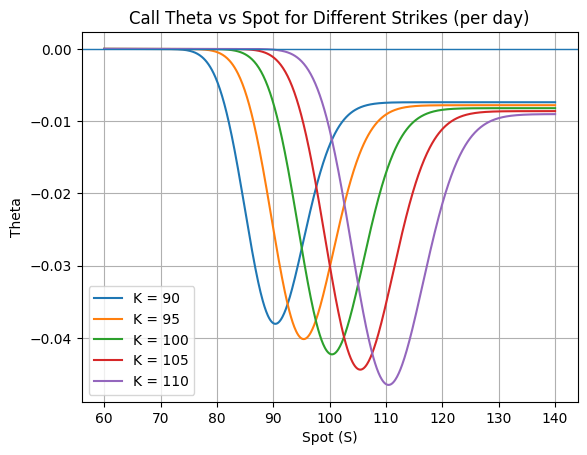

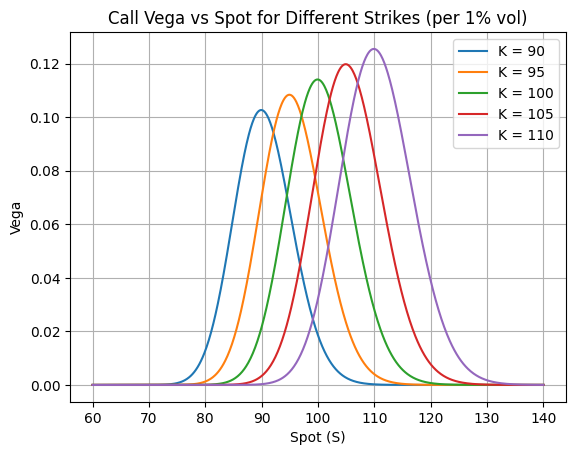

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# Black–Scholes call greeks (no dividends)
# -----------------------------
def _d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call_theta(S, K, T, r, sigma):
    """
    Theta per YEAR (standard BS convention; typically negative for calls w/o dividends).
    """
    d1, d2 = _d1_d2(S, K, T, r, sigma)
    term1 = -(S * norm.pdf(d1) * sigma) / (2.0 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)
    return term1 + term2

def bs_call_vega(S, K, T, r, sigma):
    """
    Vega per 1.00 vol (i.e., per absolute volatility unit, not per 1%).
    """
    d1, _ = _d1_d2(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

# -----------------------------
# Parameters
# -----------------------------
T = 30.0 / 365.0   # 30 days
r = 0.03
sigma = 0.20

strikes = [90, 95, 100, 105, 110]
S = np.linspace(60, 140, 800)

# Optional display conventions
theta_per_day = True    # set False to plot per-year theta
vega_per_1pct = True    # set False to plot per 1.00 vol vega

# -----------------------------
# Plot Theta
# -----------------------------
plt.figure()
for K in strikes:
    theta = bs_call_theta(S, K, T, r, sigma)
    if theta_per_day:
        theta = theta / 365.0
    plt.plot(S, theta, label=f"K = {K}")

plt.title(f"Call Theta vs Spot for Different Strikes ({'per day' if theta_per_day else 'per year'})")
plt.xlabel("Spot (S)")
plt.ylabel("Theta")
plt.axhline(0, linewidth=1)
plt.legend()
plt.grid(True)

# -----------------------------
# Plot Vega
# -----------------------------
plt.figure()
for K in strikes:
    vega = bs_call_vega(S, K, T, r, sigma)
    if vega_per_1pct:
        vega = vega / 100.0  # per 1% vol move
    plt.plot(S, vega, label=f"K = {K}")

plt.title(f"Call Vega vs Spot for Different Strikes ({'per 1% vol' if vega_per_1pct else 'per 1.00 vol'})")
plt.xlabel("Spot (S)")
plt.ylabel("Vega")
plt.legend()
plt.grid(True)

plt.show()
